Language
English            300
Kiswahili          300
Luo                300
Kalenjin           300
Sheng              300
Kikuyu             300
Swahili+English     67
Sheng+English       40
Name: count, dtype: int64
Done! Saved to cleaned_dataset.csv
Train size: (1525, 10000)
Test size : (382, 10000)
Done! Saved vectorizer.pkl and train_test_data.pkl
Naive Bayes: 0.8901
Logistic Regression: 0.9058
SVM: 0.9398

Best model saved to model.pkl
                 precision    recall  f1-score   support

        English       0.89      1.00      0.94        58
       Kalenjin       0.96      1.00      0.98        52
         Kikuyu       0.98      1.00      0.99        56
      Kiswahili       0.99      0.99      0.99        73
            Luo       1.00      1.00      1.00        47
          Sheng       0.88      0.94      0.91        67
  Sheng+English       0.75      0.33      0.46         9
Swahili+English       0.80      0.40      0.53        20

       accuracy                       

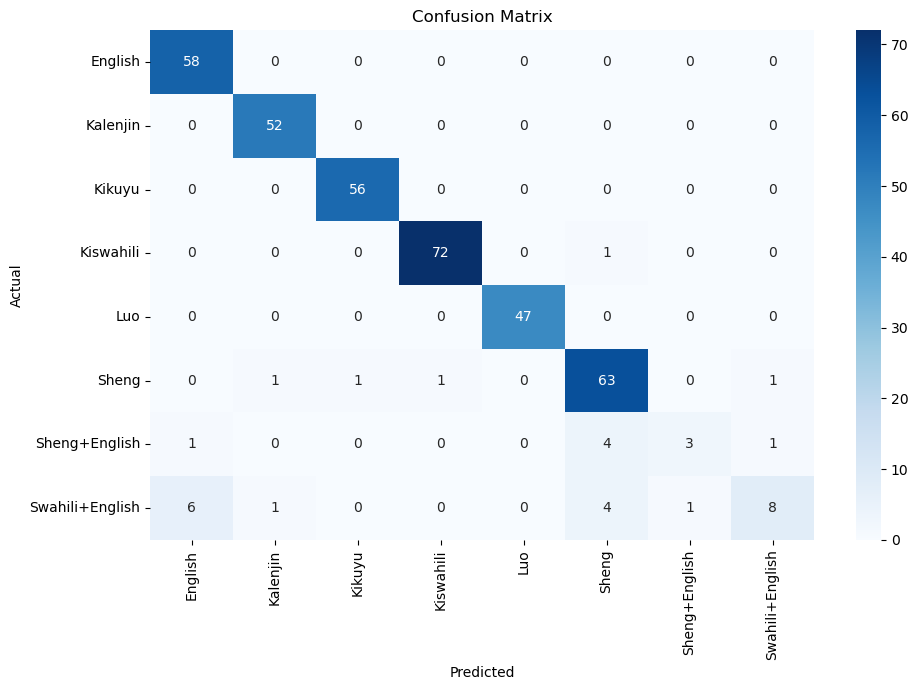

In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pickle
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
 
df = pd.read_csv("NLP Project_Languages.csv")
 
# Fix missing label
df.loc[df['Language'].isnull(), 'Language'] = 'Swahili+English'
 
# Preprocess: lowercase, remove punctuation/digits/extra spaces
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
 
df['Cleaned_Text'] = df['Text'].apply(preprocess)
 
print(df['Language'].value_counts())
 
df[['Cleaned_Text', 'Language']].to_csv("cleaned_dataset.csv", index=False)
print("Done! Saved to cleaned_dataset.csv")
 
df = pd.read_csv("cleaned_dataset.csv")
 
X = df['Cleaned_Text']
y = df['Language']
 
# TF-IDF with character n-grams (best for language identification)
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=10000)
X_vectorized = vectorizer.fit_transform(X)
 
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)
 
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
 
# Save vectorizer and splits for use in model training
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump((X_train, X_test, y_train, y_test), open("train_test_data.pkl", "wb"))
print("Done! Saved vectorizer.pkl and train_test_data.pkl")


X_train, X_test, y_train, y_test = pickle.load(open("train_test_data.pkl", "rb"))

models = {
    "Naive Bayes"        : MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM"                : LinearSVC()
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    trained[name] = model
    print(f"{name}: {acc:.4f}")

# Save best model (SVM usually wins for language ID)
pickle.dump(trained["SVM"], open("model.pkl", "wb"))
print("\nBest model saved to model.pkl")


X_train, X_test, y_train, y_test = pickle.load(open("train_test_data.pkl", "rb"))
model = pickle.load(open("model.pkl", "rb"))

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("Saved confusion_matrix.png")



pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(trained["SVM"], open("model.pkl", "wb"))
print("Done!")